# Exploratory Data Analysis -- Regression Practice

EDA of dataset used for regression practice.

## SETUP

In [1]:
import pathlib
import json
import typing as T

import datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import sklearn.feature_selection as skft
import sklearn.impute as skimp
import sklearn.preprocessing as skprep
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

## DATA COLLECTION

In [2]:
ds = datasets.load_dataset("michaelmallari/house-prices-advanced-regression-techniques")
src_df = ds["train"].to_pandas()

## EDA

In [3]:
src_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
src_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [5]:
dependent_var = "SalePrice"

In [6]:
cols_to_drop = [dependent_var, "Id"]

### Data Gap Analysis

For identifying columns with too many missing values where imputation could lead to misleading results.

In [7]:
null_cols = src_df.isnull().sum().loc[lambda x: x > 0]
null_cols

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [8]:
acceptable_percent_missing = 0.25

null_cols_to_drop = null_cols.loc[
    lambda x: x > src_df.shape[0] * acceptable_percent_missing
].index.to_list()

cols_to_drop += null_cols_to_drop
null_cols_to_drop

['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']

### Encoding Analysis

For identifying whether non-numerical columns are ordinal, interval, or simply nominal in order to determine encoding strategy.

In [9]:
def list_unique(df: pd.DataFrame | T.Iterator[pd.DataFrame], col: str) -> list[str]:
    return df.loc[:, col].unique().dropna().tolist()

In [10]:
encodable_cols = (
    src_df.loc[:, ~src_df.columns.isin(cols_to_drop)]
    .select_dtypes(["object", "str"])
    .nunique(dropna=True)
    .index
)
for col in encodable_cols:
    print(f"{col}: {list_unique(src_df, col)}")

MSZoning: ['RL', 'RM', 'C (all)', 'FV', 'RH']
Street: ['Pave', 'Grvl']
LotShape: ['Reg', 'IR1', 'IR2', 'IR3']
LandContour: ['Lvl', 'Bnk', 'Low', 'HLS']
Utilities: ['AllPub', 'NoSeWa']
LotConfig: ['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3']
LandSlope: ['Gtl', 'Mod', 'Sev']
Neighborhood: ['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst', 'NWAmes', 'OldTown', 'BrkSide', 'Sawyer', 'NridgHt', 'NAmes', 'SawyerW', 'IDOTRR', 'MeadowV', 'Edwards', 'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill', 'Blmngtn', 'BrDale', 'SWISU', 'Blueste']
Condition1: ['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', 'RRAn', 'PosA', 'RRNe']
Condition2: ['Norm', 'Artery', 'RRNn', 'Feedr', 'PosN', 'PosA', 'RRAn', 'RRAe']
BldgType: ['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs']
HouseStyle: ['2Story', '1Story', '1.5Fin', '1.5Unf', 'SFoyer', 'SLvl', '2.5Unf', '2.5Fin']
RoofStyle: ['Gable', 'Hip', 'Gambrel', 'Mansard', 'Flat', 'Shed']
RoofMatl: ['CompShg', 'WdShngl', 'Metal', 'WdShake', 'Membran'

### Distribution Analysis

For determining skewness, modalities, kurtosis, outliers, and imputation and standardization strategies.

In [11]:
def plot_eda_kdes(df: pd.DataFrame | T.Iterator[pd.DataFrame]):
    numerical_features = df.select_dtypes(include=["number"]).columns
    num_features = len(numerical_features)
    if num_features % 2 != 0:
        num_features += 1

    plt.figure(figsize=(15, num_features * 3))
    for idx, feature in enumerate(numerical_features, 1):
        plt.subplot(num_features, 2, idx)
        sns.histplot(df[feature], kde=True)
        plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

    plt.tight_layout()
    plt.show()

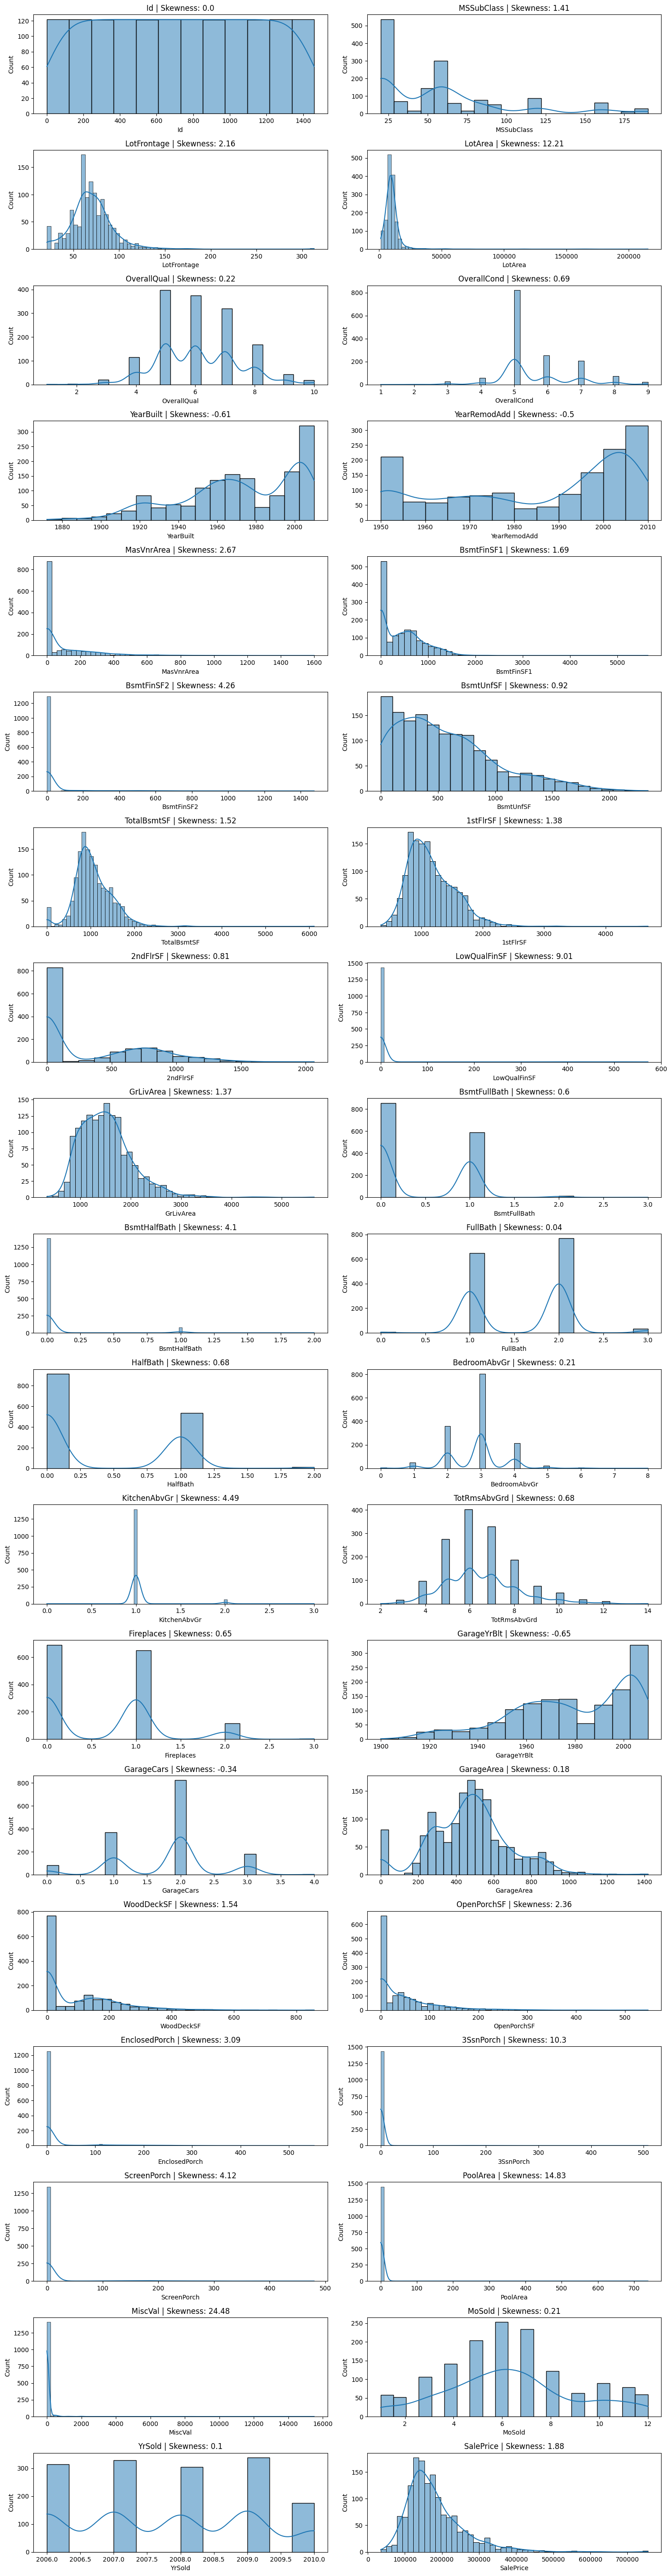

In [12]:
plot_eda_kdes(src_df)

## FEATURE ENGINEERING

In [13]:
prep_df = src_df.loc[:, ~src_df.columns.isin(cols_to_drop)]
prep_df = (
    skimp.SimpleImputer(missing_values=pd.NA, strategy="most_frequent")
    .set_output(transform="pandas")
    .fit_transform(prep_df)
)
prep_df = pd.get_dummies(prep_df, columns=encodable_cols, drop_first=True, dtype="int")

for col in prep_df.columns:  # cube root transformation to manage right-skew
    if col != dependent_var:
        prep_df.loc[:, col] = np.cbrt(prep_df[col].astype("float64"))

prep_df = skprep.StandardScaler().set_output(transform="pandas").fit_transform(prep_df)

### Feature Selection

For dimensionality reduction.

In [14]:
def plot_feat_selector(selector_df: pd.DataFrame | T.Iterator[pd.DataFrame]):
    plt.figure(figsize=(20, 40))
    sns.barplot(selector_df, x="score", y="feature", legend=False)
    plt.title("Features by F-Test Scores")
    plt.show()

In [15]:
selector = skft.SelectKBest(score_func=skft.f_regression, k="all")
selector.fit(prep_df, src_df[dependent_var])
selector_df = pd.DataFrame(
    {"feature": prep_df.columns, "score": selector.scores_}
).sort_values("score", ascending=False)

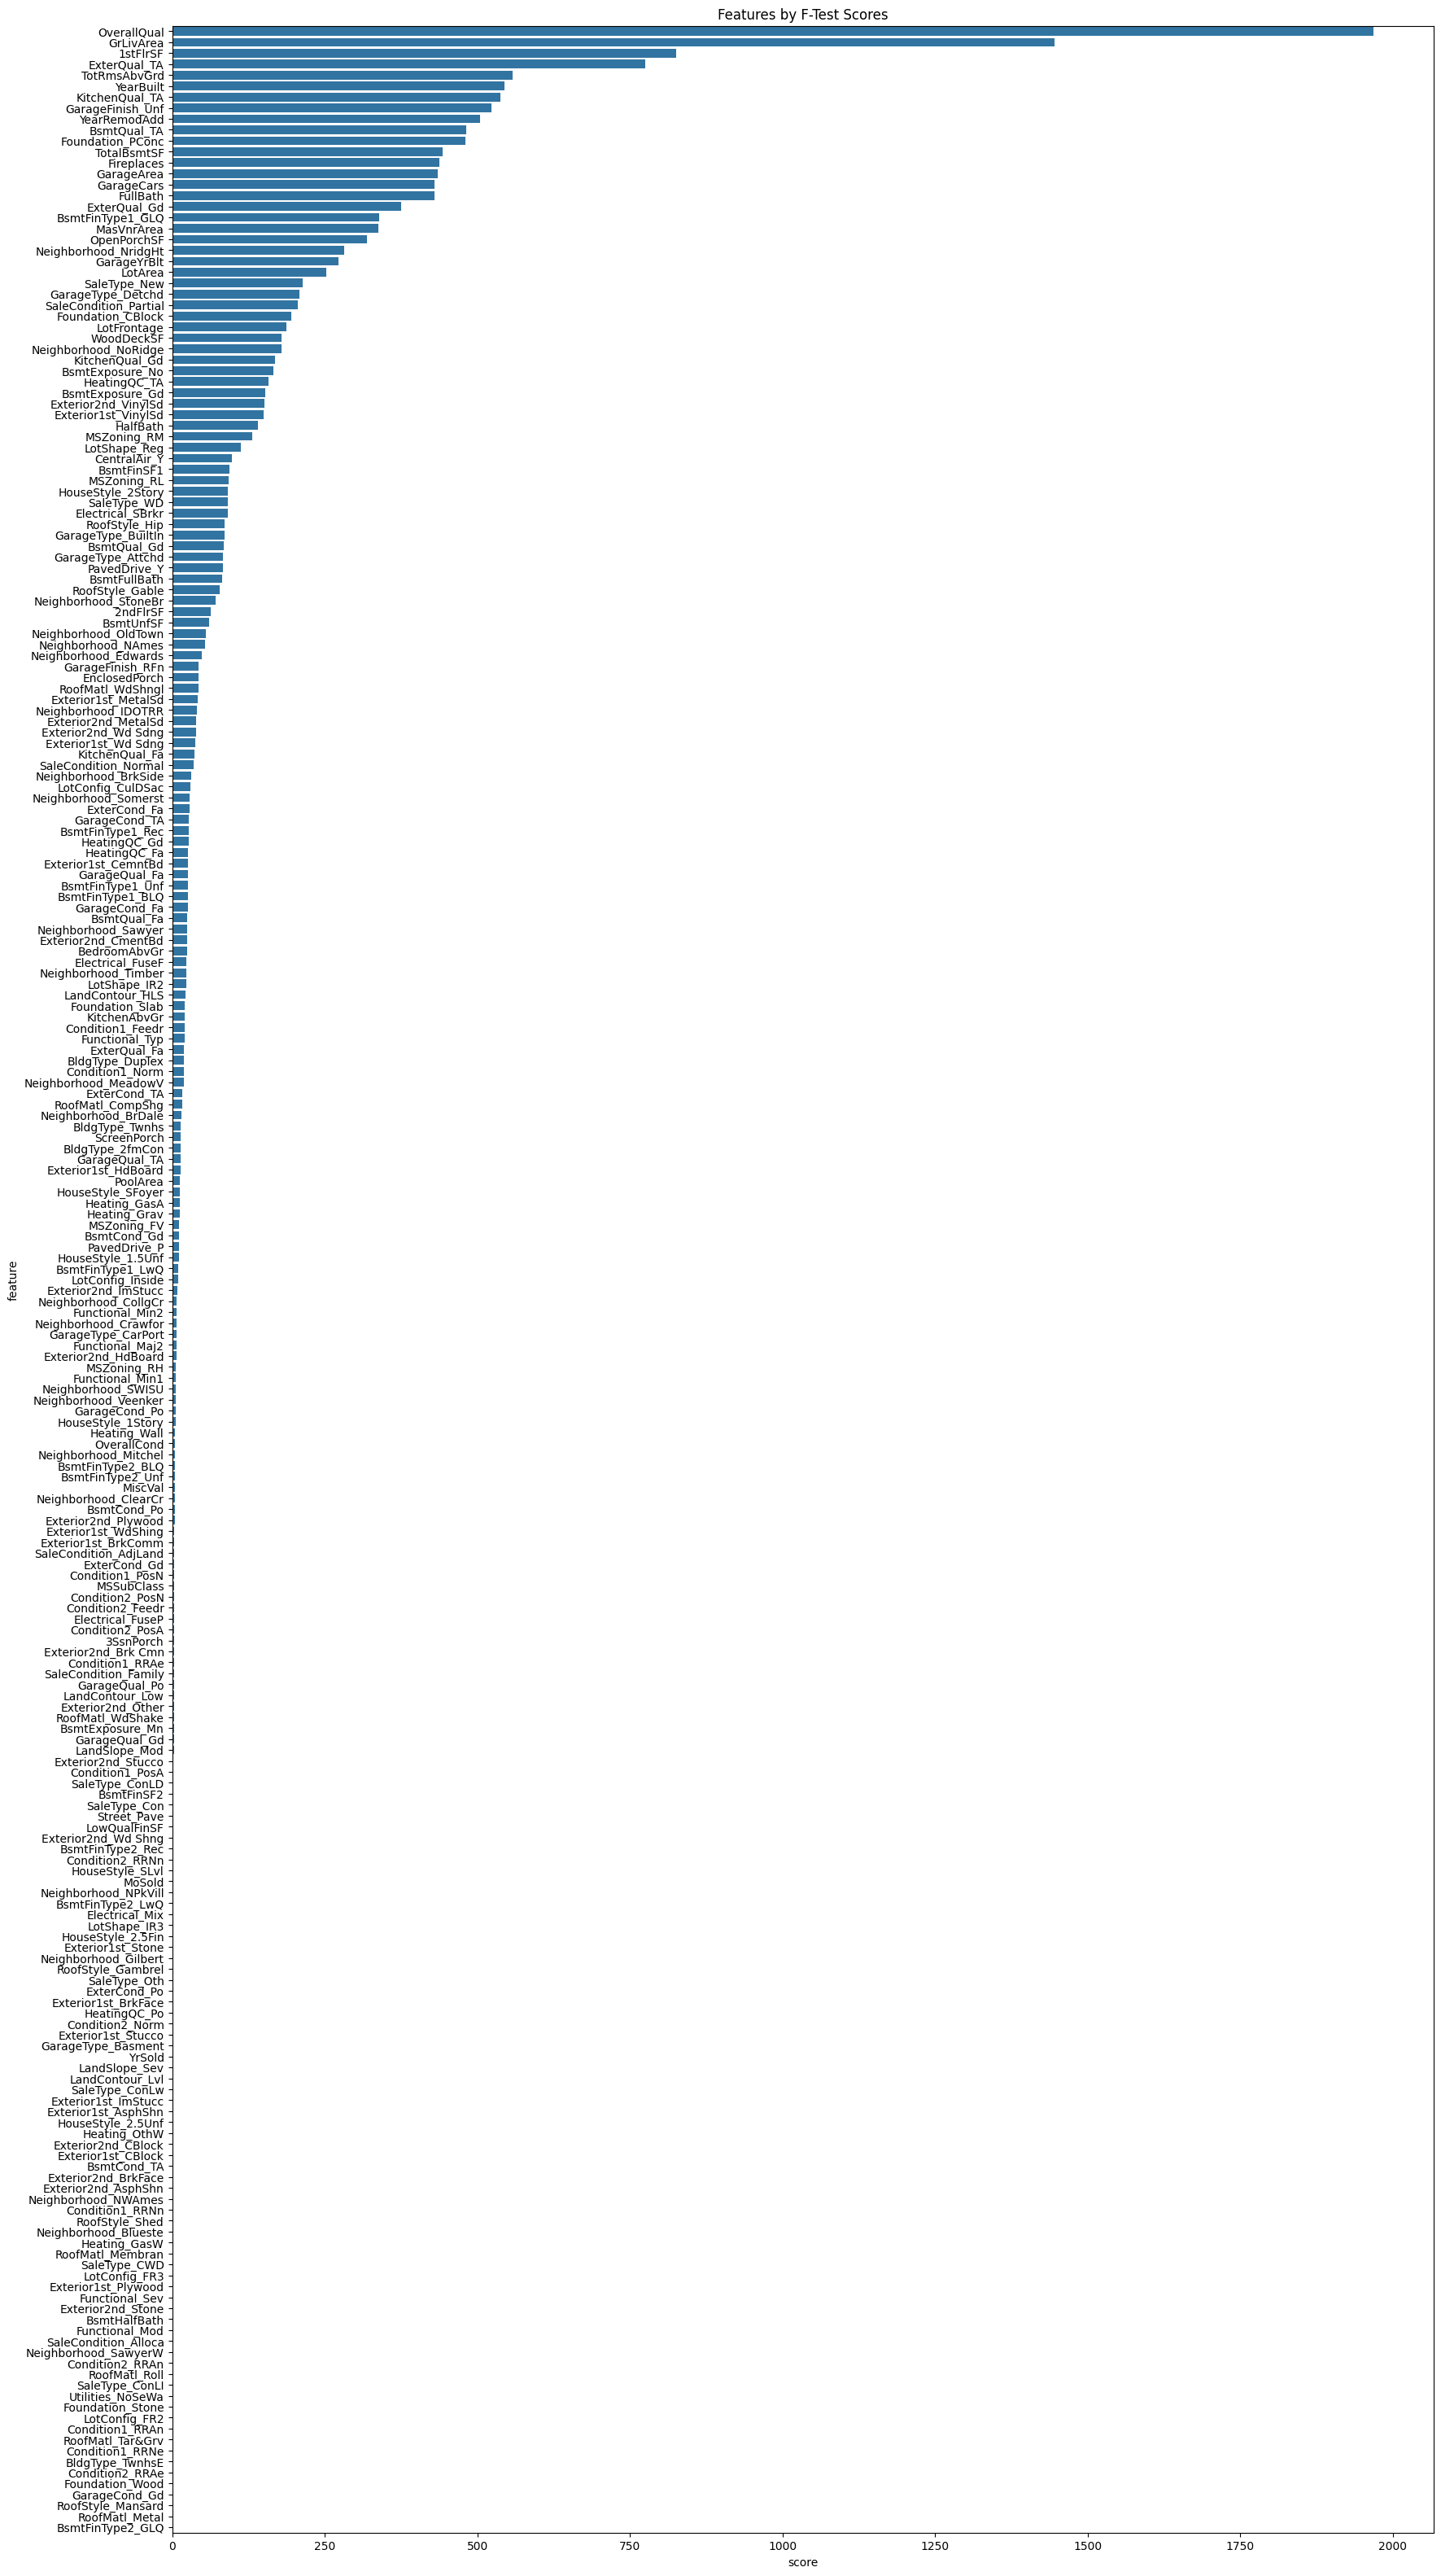

In [16]:
plot_feat_selector(selector_df)

In [17]:
selected_features = (
    selector_df.loc[selector_df["score"] > selector_df["score"].quantile(0.5)]
    .loc[:, "feature"]
    .to_list()
)
selected_features

['OverallQual',
 'GrLivArea',
 '1stFlrSF',
 'ExterQual_TA',
 'TotRmsAbvGrd',
 'YearBuilt',
 'KitchenQual_TA',
 'GarageFinish_Unf',
 'YearRemodAdd',
 'BsmtQual_TA',
 'Foundation_PConc',
 'TotalBsmtSF',
 'Fireplaces',
 'GarageArea',
 'GarageCars',
 'FullBath',
 'ExterQual_Gd',
 'BsmtFinType1_GLQ',
 'MasVnrArea',
 'OpenPorchSF',
 'Neighborhood_NridgHt',
 'GarageYrBlt',
 'LotArea',
 'SaleType_New',
 'GarageType_Detchd',
 'SaleCondition_Partial',
 'Foundation_CBlock',
 'LotFrontage',
 'WoodDeckSF',
 'Neighborhood_NoRidge',
 'KitchenQual_Gd',
 'BsmtExposure_No',
 'HeatingQC_TA',
 'BsmtExposure_Gd',
 'Exterior2nd_VinylSd',
 'Exterior1st_VinylSd',
 'HalfBath',
 'MSZoning_RM',
 'LotShape_Reg',
 'CentralAir_Y',
 'BsmtFinSF1',
 'MSZoning_RL',
 'HouseStyle_2Story',
 'SaleType_WD',
 'Electrical_SBrkr',
 'RoofStyle_Hip',
 'GarageType_BuiltIn',
 'BsmtQual_Gd',
 'GarageType_Attchd',
 'PavedDrive_Y',
 'BsmtFullBath',
 'RoofStyle_Gable',
 'Neighborhood_StoneBr',
 '2ndFlrSF',
 'BsmtUnfSF',
 'Neighborhood

### Correlation Analysis

For addressing multicollinearity.

In [18]:
prep_df = prep_df.loc[:, selected_features]

In [19]:
def plot_corr_matrix(corr_matrix_df: pd.DataFrame | T.Iterator[pd.DataFrame]):
    plt.figure(figsize=(20, 20))
    sns.heatmap(corr_matrix_df, cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.show()

#### Pairwise Correlation

In [20]:
corr_matrix_df = prep_df.corr(method="kendall")

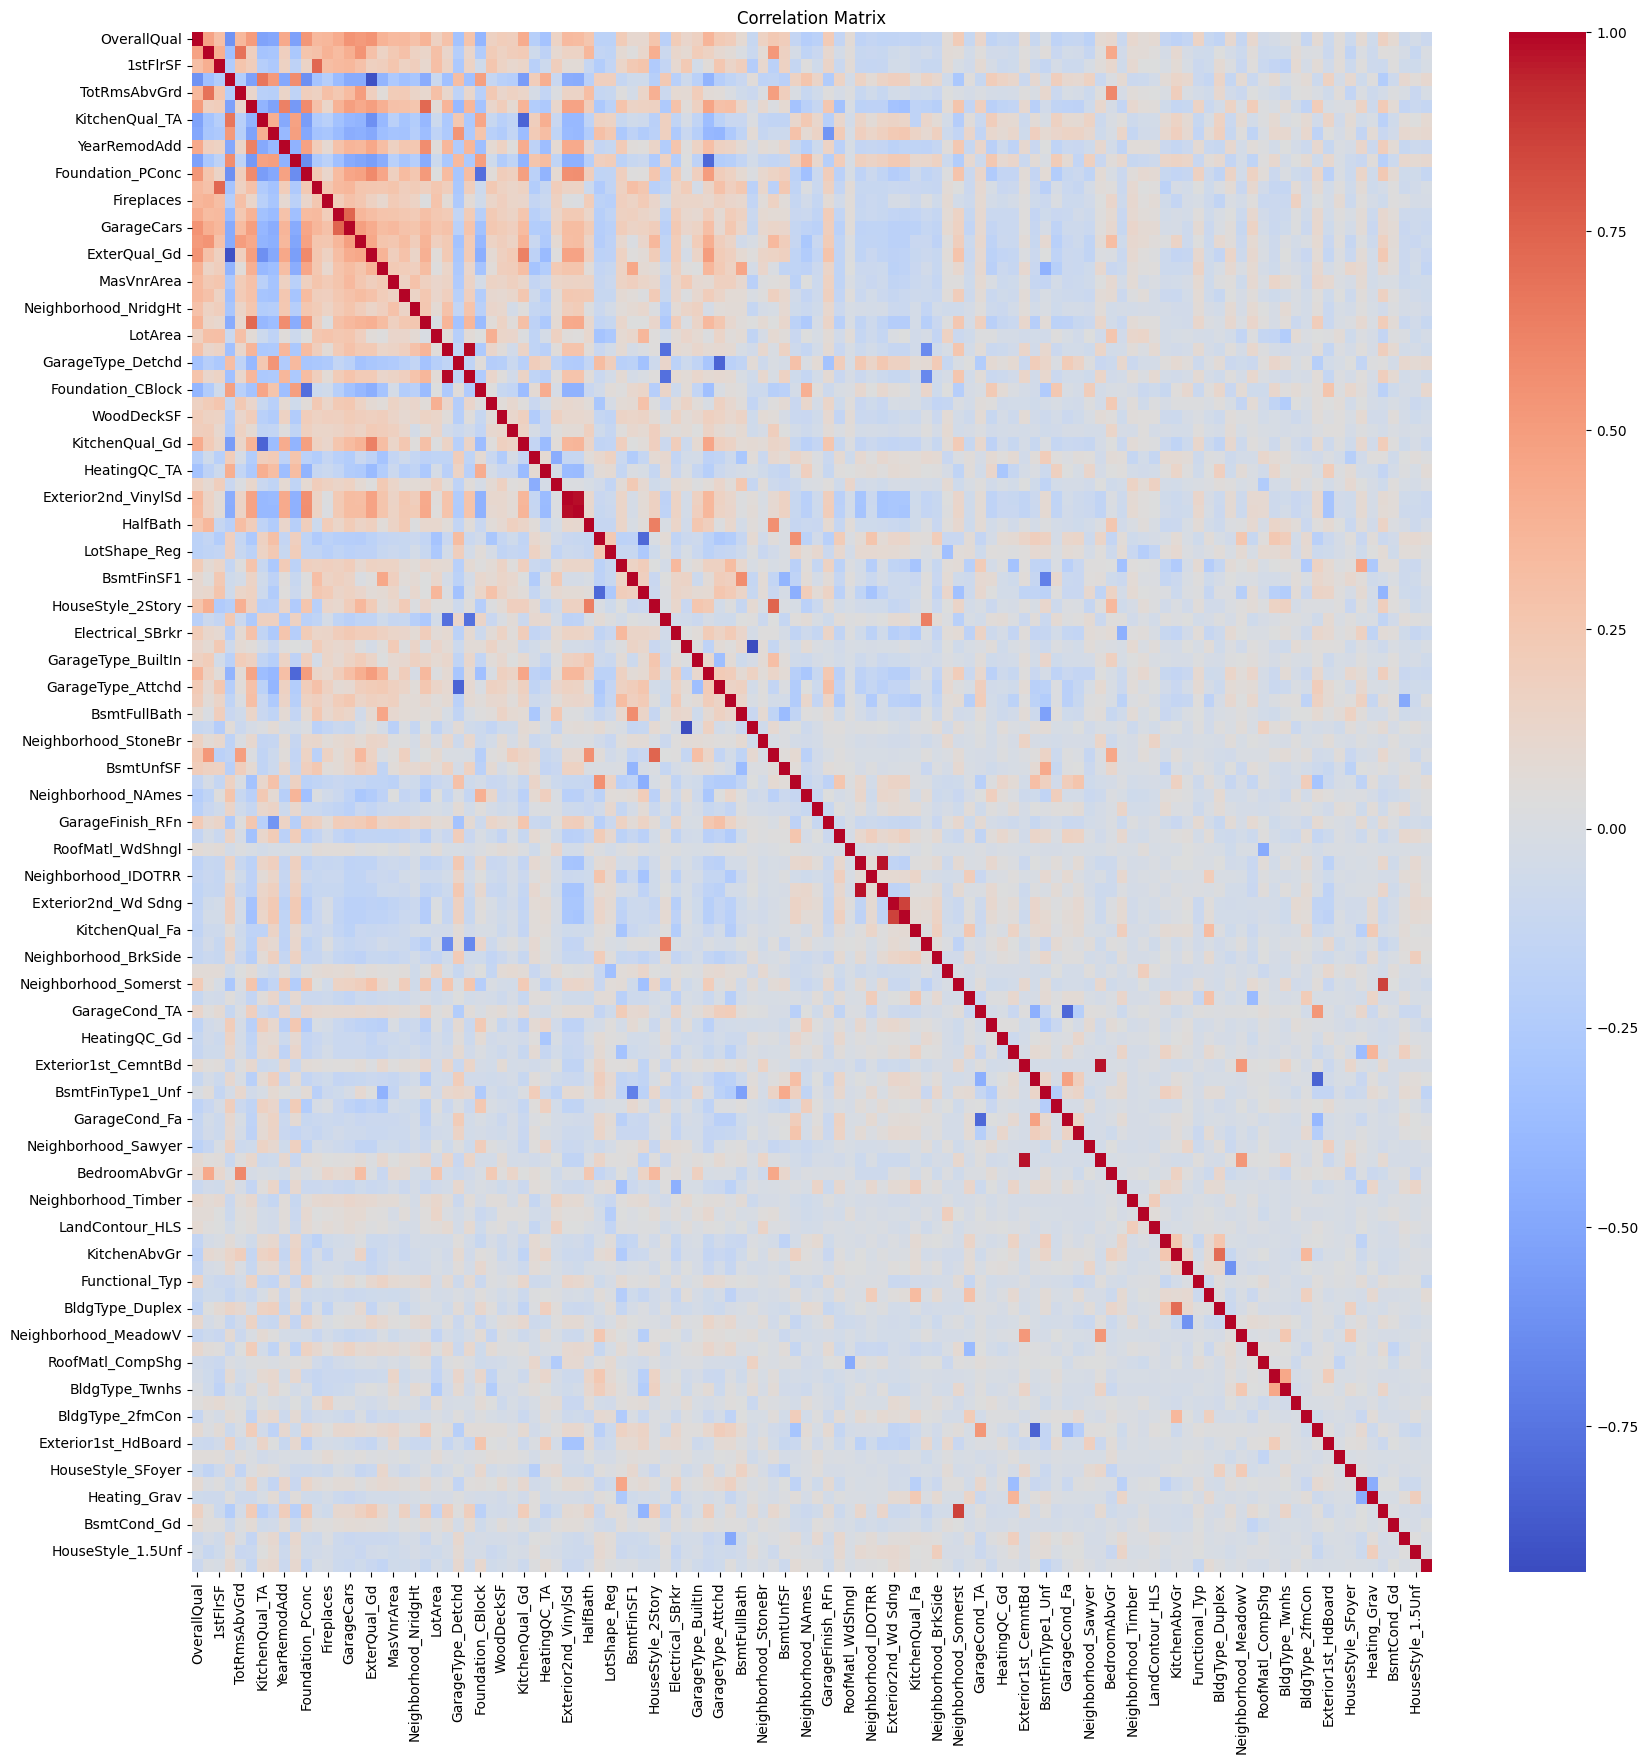

In [21]:
plot_corr_matrix(corr_matrix_df)

In [22]:
corr_threshold = 0.8
upper_tri = corr_matrix_df.where(
    np.triu(np.ones(corr_matrix_df.shape), k=1).astype(bool)
)

high_corr_pairs = [
    col for col in upper_tri.columns if any(upper_tri[col].abs() > corr_threshold)
]

cols_to_drop += high_corr_pairs
high_corr_pairs

['ExterQual_Gd',
 'SaleCondition_Partial',
 'KitchenQual_Gd',
 'Exterior1st_VinylSd',
 'MSZoning_RL',
 'BsmtQual_Gd',
 'GarageType_Attchd',
 'RoofStyle_Gable',
 'Exterior2nd_MetalSd',
 'Exterior1st_Wd Sdng',
 'GarageCond_Fa',
 'Exterior2nd_CmentBd',
 'GarageQual_TA',
 'MSZoning_FV']

#### Variance Inflation Factors

In [23]:
prep_df = prep_df.drop(high_corr_pairs, axis=1)

In [24]:
def calc_vif(
    src_df: pd.DataFrame, vif_to_drop: list[str] = []
) -> tuple[pd.DataFrame, list[str]]:
    df = src_df.copy()
    df = sm.add_constant(df)  # for intercept

    vif_df = pd.DataFrame()
    vif_df.loc[:, "variable"] = df.columns
    vif_df.loc[:, "vif"] = [vif(df.values, i) for i in range(df.shape[1])]
    vif_df = vif_df.sort_values(by="vif", ascending=False).reset_index(drop=True)

    to_drop = vif_df.loc[vif_df["vif"] == float("inf")].loc[:, "variable"].to_list()

    if vif_df.at[0, "vif"] > 5:
        to_drop += [vif_df.at[0, "variable"]]
        print(to_drop)

        return calc_vif(df.drop(to_drop + ["const"], axis=1), vif_to_drop + to_drop)

    return vif_df, vif_to_drop

In [25]:
vif_df, vif_to_drop = calc_vif(prep_df)
vif_df

['GrLivArea']
['GarageCars']
['BsmtFinSF1']
['YearBuilt']
['2ndFlrSF']
['Foundation_PConc']
['TotalBsmtSF']


,variable,vif
0,1stFlrSF,4.602543
1,TotRmsAbvGrd,3.905440
2,OverallQual,3.867422
3,SaleType_New,3.529166
4,BsmtFinType1_Unf,3.471491
...,...,...
89,LandContour_HLS,1.185429
90,ScreenPorch,1.144148
91,PoolArea,1.129615
92,BsmtCond_Gd,1.122119


In [26]:
cols_to_drop += vif_to_drop
vif_to_drop

['GrLivArea',
 'GarageCars',
 'BsmtFinSF1',
 'YearBuilt',
 '2ndFlrSF',
 'Foundation_PConc',
 'TotalBsmtSF']

## Results

In [27]:
cols_to_drop = [col for col in cols_to_drop if col != dependent_var]
selected_features = list(set(selected_features).difference(cols_to_drop))

In [28]:
with open(pathlib.Path(".", "selected-features.json"), "w") as f:
    json.dump(selected_features, f)

In [29]:
prep_df[selected_features]

,ExterQual_TA,LandContour_HLS,BsmtFinType1_Unf,TotRmsAbvGrd,YearRemodAdd,CentralAir_Y,GarageFinish_RFn,BsmtUnfSF,Neighborhood_StoneBr,1stFlrSF,...,HouseStyle_1.5Unf,LotConfig_CulDSac,Exterior1st_HdBoard,Condition1_Norm,Neighborhood_NAmes,Condition1_Feedr,ExterCond_Fa,Neighborhood_Timber,LotFrontage,BsmtCond_Gd
0,-1.278819,-0.188311,-0.685778,0.942169,0.877918,0.263813,1.568348,-0.704482,-0.131991,-0.812830,...,-0.098397,-0.262324,-0.423464,0.39841,-0.426833,-0.242360,-0.139832,-0.163471,-0.052066,-0.215859
1,0.781971,-0.188311,-0.685778,-0.248529,-0.425983,0.263813,1.568348,-0.275079,-0.131991,0.369866,...,-0.098397,-0.262324,-0.423464,-2.50998,-0.426833,4.126099,-0.139832,-0.163471,0.627581,-0.215859
2,-1.278819,-0.188311,-0.685778,-0.248529,0.829835,0.263813,1.568348,0.065089,-0.131991,-0.604562,...,-0.098397,-0.262324,-0.423464,0.39841,-0.426833,-0.242360,-0.139832,-0.163471,0.091649,-0.215859
3,0.781971,-0.188311,-0.685778,0.375279,-0.717350,0.263813,-0.637614,0.260075,-0.131991,-0.476173,...,-0.098397,-0.262324,-0.423464,0.39841,-0.426833,-0.242360,-0.139832,-0.163471,-0.301754,4.632660
4,-1.278819,-0.188311,-0.685778,1.463582,0.733621,0.263813,1.568348,0.171622,-0.131991,0.058916,...,-0.098397,-0.262324,-0.423464,0.39841,-0.426833,-0.242360,-0.139832,-0.163471,0.794223,-0.215859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0.781971,-0.188311,1.458197,0.375279,0.733621,0.263813,1.568348,0.838668,-0.131991,-0.500934,...,-0.098397,-0.262324,-0.423464,0.39841,-0.426833,-0.242360,-0.139832,-0.163471,-0.200273,-0.215859
1456,0.781971,-0.188311,-0.685778,0.375279,0.154986,0.263813,-0.637614,0.341608,-0.131991,2.122913,...,-0.098397,-0.262324,-0.423464,0.39841,-0.426833,-0.242360,-0.139832,-0.163471,0.835054,-0.215859
1457,-1.278819,-0.188311,-0.685778,1.463582,1.022071,0.263813,1.568348,0.747025,-0.131991,0.175557,...,-0.098397,-0.262324,-0.423464,0.39841,-0.426833,-0.242360,-0.139832,-0.163471,-0.003678,4.632660
1458,0.781971,-0.188311,-0.685778,-0.946130,0.541000,0.263813,-0.637614,-2.515453,-0.131991,-0.128793,...,-0.098397,-0.262324,-0.423464,0.39841,2.342838,-0.242360,-0.139832,-0.163471,0.091649,-0.215859
